<a href="https://colab.research.google.com/github/Siam-Khandaker-Anonto/EDA-stuffs/blob/main/MSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mp-api pandas matplotlib seaborn scikit-learn pymatgen

In [ ]:
!pip install matminer

In [ ]:
from mp_api.client import MPRester
import pandas as pd


with MPRester("iw6Hr8xdPOXdFmwJK2W6qfc0hNbGsJj4") as mpr:

  docs = mpr.materials.summary.search(
      elements=["C"],
      band_gap=(0,5),
      fields=["material_id", "formula_pretty", "formation_energy_per_atom",
                "band_gap", "density", "volume", "symmetry", "energy_above_hull"],
      num_chunks=1,
      chunk_size=1000
  )

df = pd.DataFrame([doc.dict() for doc in docs])
df.shape

Retrieving SummaryDoc documents:   0%|          | 0/1000 [00:00<?, ?it/s]

(1000, 10)

In [ ]:
df.head()

,material_id,formation_energy_per_atom,symmetry,volume,band_gap,formula_pretty,energy_above_hull,density,fields_not_requested,unavailable_fields
0,mp-aaahikmi,-1.471054,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",300.766449,1.2657,KCO3,0.060310,2.188693,"[num_unique_magnetic_sites, theoretical, is_ga...",[]
1,mp-aaahilqv,0.000000,"{'crystal_system': 'Monoclinic', 'symbol': 'C2...",18.329779,1.3762,C,0.000000,2.176157,"[num_unique_magnetic_sites, theoretical, is_ga...",[]
2,mp-aaadjxvf,-1.467794,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",326.974909,1.4990,KCO3,0.063571,2.013260,"[num_unique_magnetic_sites, theoretical, is_ga...",[]
3,mp-aaadjycr,-1.479828,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",329.353835,1.4885,KCO3,0.051537,1.998718,"[num_unique_magnetic_sites, theoretical, is_ga...",[]
4,mp-aaadlpam,-2.342991,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",650.089257,2.5231,Na3VPCO7,0.037561,2.808644,"[num_unique_magnetic_sites, theoretical, is_ga...",[]


In [ ]:
df = df[df['energy_above_hull'] < 0.05]
df.head()

,material_id,formation_energy_per_atom,symmetry,volume,band_gap,formula_pretty,energy_above_hull,density,fields_not_requested,unavailable_fields
1,mp-aaahilqv,0.000000,"{'crystal_system': 'Monoclinic', 'symbol': 'C2...",18.329779,1.3762,C,0.000000,2.176157,"[num_unique_magnetic_sites, theoretical, is_ga...",[]
4,mp-aaadlpam,-2.342991,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",650.089257,2.5231,Na3VPCO7,0.037561,2.808644,"[num_unique_magnetic_sites, theoretical, is_ga...",[]
5,mp-aaadlqtg,-2.285412,"{'crystal_system': 'Triclinic', 'symbol': 'P-1...",767.851727,3.6584,K3FePCO7,0.001930,2.838341,"[num_unique_magnetic_sites, theoretical, is_ga...",[]
10,mp-aaadlxzi,-2.234843,"{'crystal_system': 'Triclinic', 'symbol': 'P-1...",755.511522,2.9167,K3CoPCO7,0.003058,2.911852,"[num_unique_magnetic_sites, theoretical, is_ga...",[]
11,mp-aaadprho,-2.394676,"{'crystal_system': 'Triclinic', 'symbol': 'P-1...",745.189905,0.0000,K2VPCO7,0.037950,2.532453,"[num_unique_magnetic_sites, theoretical, is_ga...",[]


In [ ]:
df = df.drop_duplicates(subset=['material_id'])

In [ ]:
df.isnull().sum()

,0
material_id,0
formation_energy_per_atom,0
symmetry,0
volume,0
band_gap,0
formula_pretty,0
energy_above_hull,0
density,0
fields_not_requested,0
unavailable_fields,0


In [ ]:
df = df[df["formation_energy_per_atom"] > -5]
df = df[df["formation_energy_per_atom"] < 2]

In [ ]:
df = df[df["band_gap"] >= 0]

In [ ]:
df = df[~df["formula_pretty"].str.contains("XXXX", na=False)]

In [ ]:
df.shape

(394, 10)

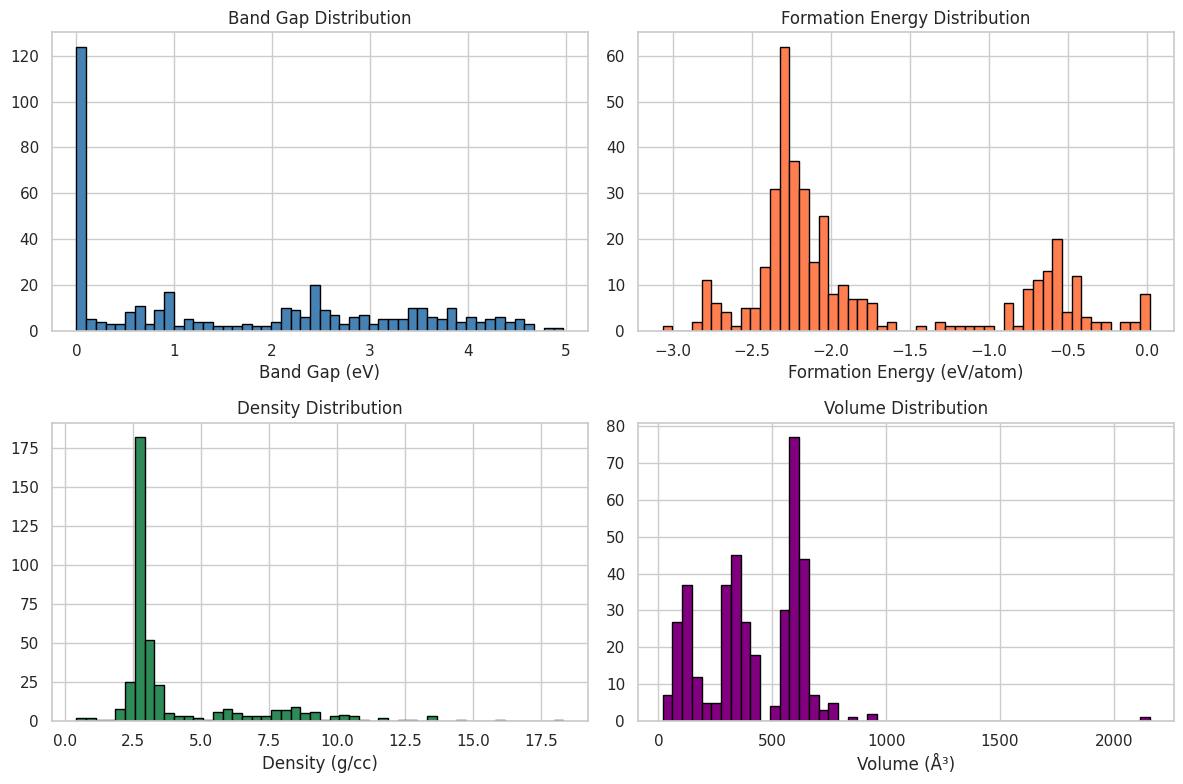

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["band_gap"], bins=50, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Band Gap Distribution")
axes[0, 0].set_xlabel("Band Gap (eV)")

axes[0, 1].hist(df["formation_energy_per_atom"], bins=50, color="coral", edgecolor="black")
axes[0, 1].set_title("Formation Energy Distribution")
axes[0, 1].set_xlabel("Formation Energy (eV/atom)")

axes[1, 0].hist(df["density"], bins=50, color="seagreen", edgecolor="black")
axes[1, 0].set_title("Density Distribution")
axes[1, 0].set_xlabel("Density (g/cc)")

axes[1, 1].hist(df["volume"], bins=50, color="purple", edgecolor="black")
axes[1, 1].set_title("Volume Distribution")
axes[1, 1].set_xlabel("Volume (Å³)")

plt.tight_layout()
plt.show()

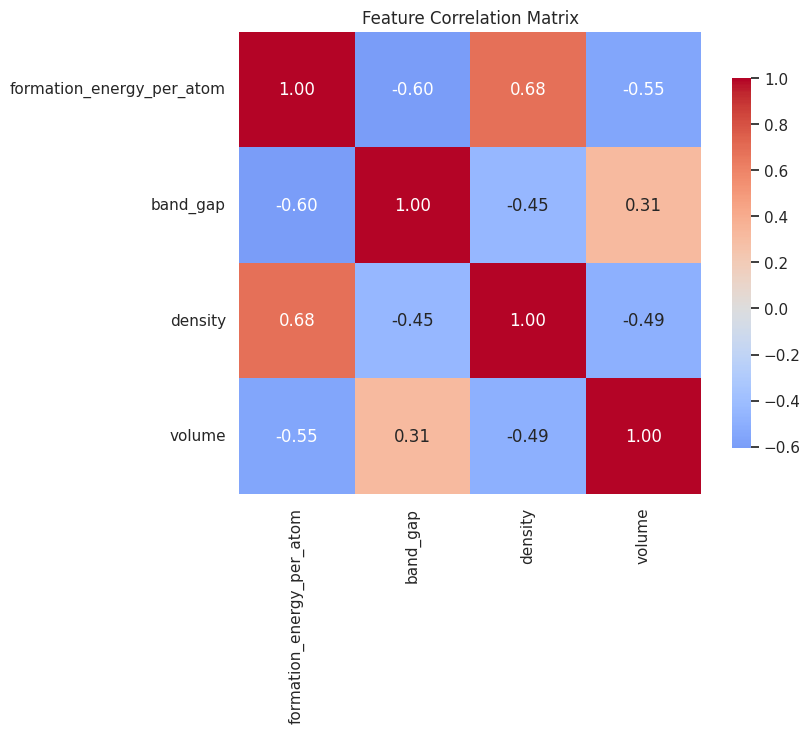

In [ ]:
numerical_cols = ["formation_energy_per_atom", "band_gap", "density", "volume"]
corr_matrix = df[numerical_cols].corr()


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0,
            square=True, fmt=".2f", cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix")
plt.show()

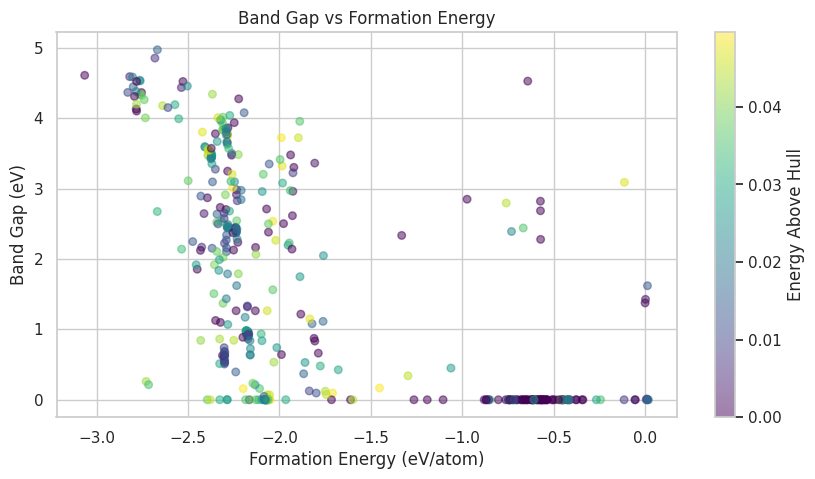

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(df["formation_energy_per_atom"], df["band_gap"],
            alpha=0.5, c=df["energy_above_hull"], cmap="viridis", s=30)
plt.colorbar(label="Energy Above Hull")
plt.xlabel("Formation Energy (eV/atom)")
plt.ylabel("Band Gap (eV)")
plt.title("Band Gap vs Formation Energy")
plt.show()

In [ ]:
from pymatgen.core import Composition
import numpy as np

def get_composition_features(formula):
    """Convert formula to average elemental properties"""
    try:
        comp = Composition(formula)
        elements = comp.elements

        # Average atomic number (weighted by fraction)
        avg_Z = np.average([el.Z for el in elements], weights=[comp[el] for el in elements])

        # Average electronegativity (Pauling scale)
        # This is a simplification - real implementation needs a lookup table
        electronegativity = {"H":2.20, "He":None, "Li":0.98, "Be":1.57, "B":2.04,
                             "C":2.55, "N":3.04, "O":3.44, "F":3.98, "Na":0.93,
                             "Mg":1.31, "Al":1.61, "Si":1.90, "P":2.19, "S":2.58,
                             "Cl":3.16, "K":0.82, "Ca":1.00, "Fe":1.83, "Ni":1.91,
                             "Cu":1.90, "Zn":1.65, "Ga":1.81, "Ge":2.01, "As":2.18,
                             "Se":2.55, "Br":2.96, "Ag":1.93, "Au":2.54}

        avg_EN = np.average([electronegativity.get(el.symbol, 2.0) for el in elements],
                           weights=[comp[el] for el in elements])

        return avg_Z, avg_EN
    except:
        return np.nan, np.nan

# Apply to your dataframe
df["avg_Z"], df["avg_EN"] = zip(*df["formula_pretty"].apply(get_composition_features))

# Drop rows where feature engineering failed
df = df.dropna(subset=["avg_Z", "avg_EN"])

In [ ]:
df.head()

,material_id,formation_energy_per_atom,symmetry,volume,band_gap,formula_pretty,energy_above_hull,density,fields_not_requested,unavailable_fields,avg_Z,avg_EN
1,mp-aaahilqv,0.000000,"{'crystal_system': 'Monoclinic', 'symbol': 'C2...",18.329779,1.3762,C,0.000000,2.176157,"[num_unique_magnetic_sites, theoretical, is_ga...",[],6.000000,2.550000
4,mp-aaadlpam,-2.342991,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",650.089257,2.5231,Na3VPCO7,0.037561,2.808644,"[num_unique_magnetic_sites, theoretical, is_ga...",[],10.230769,2.585385
5,mp-aaadlqtg,-2.285412,"{'crystal_system': 'Triclinic', 'symbol': 'P-1...",767.851727,3.6584,K3FePCO7,0.001930,2.838341,"[num_unique_magnetic_sites, theoretical, is_ga...",[],12.307692,2.546923
10,mp-aaadlxzi,-2.234843,"{'crystal_system': 'Triclinic', 'symbol': 'P-1...",755.511522,2.9167,K3CoPCO7,0.003058,2.911852,"[num_unique_magnetic_sites, theoretical, is_ga...",[],12.384615,2.560000
11,mp-aaadprho,-2.394676,"{'crystal_system': 'Triclinic', 'symbol': 'P-1...",745.189905,0.0000,K2VPCO7,0.037950,2.532453,"[num_unique_magnetic_sites, theoretical, is_ga...",[],11.500000,2.705000


In [ ]:
df.columns

Index(['material_id', 'formation_energy_per_atom', 'symmetry', 'volume',
       'band_gap', 'formula_pretty', 'energy_above_hull', 'density',
       'fields_not_requested', 'unavailable_fields', 'avg_Z', 'avg_EN'],
      dtype='object')

In [ ]:
feat_cols = ['volume', 'formation_energy_per_atom', 'density','energy_above_hull','avg_Z', 'avg_EN']

X = df[feat_cols]
y = df['band_gap']
X.head()

,volume,formation_energy_per_atom,density,energy_above_hull,avg_Z,avg_EN
1,18.329779,0.000000,2.176157,0.000000,6.000000,2.550000
4,650.089257,-2.342991,2.808644,0.037561,10.230769,2.585385
5,767.851727,-2.285412,2.838341,0.001930,12.307692,2.546923
10,755.511522,-2.234843,2.911852,0.003058,12.384615,2.560000
11,745.189905,-2.394676,2.532453,0.037950,11.500000,2.705000


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf = RandomForestRegressor(n_estimators=500,max_depth=20, random_state=42)

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

In [ ]:
mean_absolute_error(y_test, y_pred)

0.5536636373041156

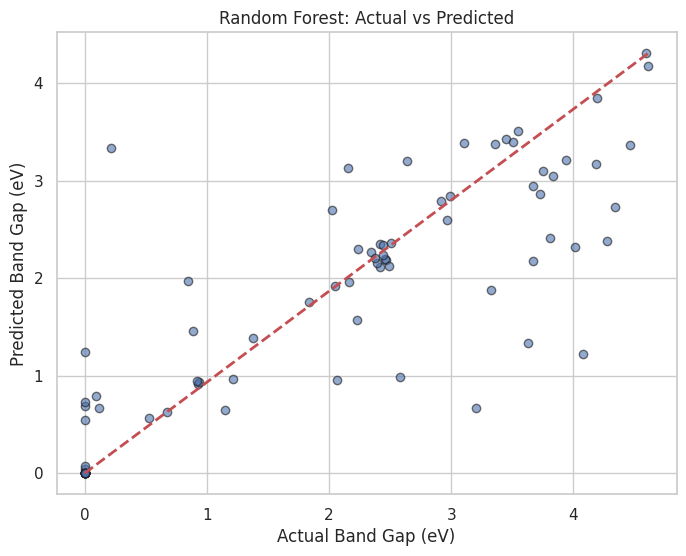

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], 'r--', lw=2)
plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Random Forest: Actual vs Predicted")
plt.show()